# Why is this important?

Well, when considering the best neighborhood, there are a couple of different factors that each person values most. Of which, a common one is safety. The easiest metric for measuring such is by volume of crime. So after surveying all the different data that's accumulated on file, we have decided that measuring crime based on the current year can properly gauge the current scope of safety concerns within the city. 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

crime = 'bd41992a-987a-4cca-8798-fbe1cd946b07-2.csv'
pd.read_csv(crime, low_memory = False)

,_id,Report_Number,ReportedDate,ReportedTime,Hour,DayofWeek,ReportedMonth,NIBRS_Coded_Offense,NIBRS_Offense_Code,NIBRS_Offense_Category,NIBRS_Offense_Type,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,XCOORD,YCOORD,Zone,Tract,Neighborhood,Block_Address
0,1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,Person,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
1,2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
2,3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
3,4,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,Property,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
4,5,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,Group B,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76172,76173,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,13B SIMPLE ASSAULT,13B,Assault Offenses,Simple Assault,Person,A,18 2701 A1 Simple Assault-General,-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"
76173,76174,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,18 907 A Possess Instruments of Crime with Intent,-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"
76174,76175,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"
76175,76176,PGHP25134833,2025-09-01,20:52,20,Monday,Sep,520 WEAPON LAW VIOLATIONS,520,Weapon Law Violations,Weapon Law Violations,Society,A,"18 6105 A1 Persons Not to Possess, Use, Manufa...",-79.9652,40.4491,Zone 2,NaN,NaN,"500 BLOCK OF HERRON AVE PITTSBURGH, PA"


# What can we understand from this?

On the surface, this CSV file is titled in a way that makes the data seem like it's contained in only the most recent month. However, upon inspection, the data actually measures the total crime in 2025, leading up to the last full month. In order to extract relevant information from this, we must consider what data brings us to a metric that could be deemed worthy of a 'best neighborhood'. To be clear, we need a way to group crime quantities on a per-neighborhood basis, whilst also having a unique way to identify them. The most relevant columns for this, after converting the CSV into a DataFrame, are '_id' and 'Neighborhood.' This is because '_id' acts as an incidence number from the first crime of 2025 all the way up to the latest crime reported. To accurately utilize this column, the 'Neighborhood' column keeps track of every crime committed within a specific neighborhood. By grouping all like neighborhoods, the unique id number can be summed to determine the total number of crimes committed/reported within a certain neighborhood. 

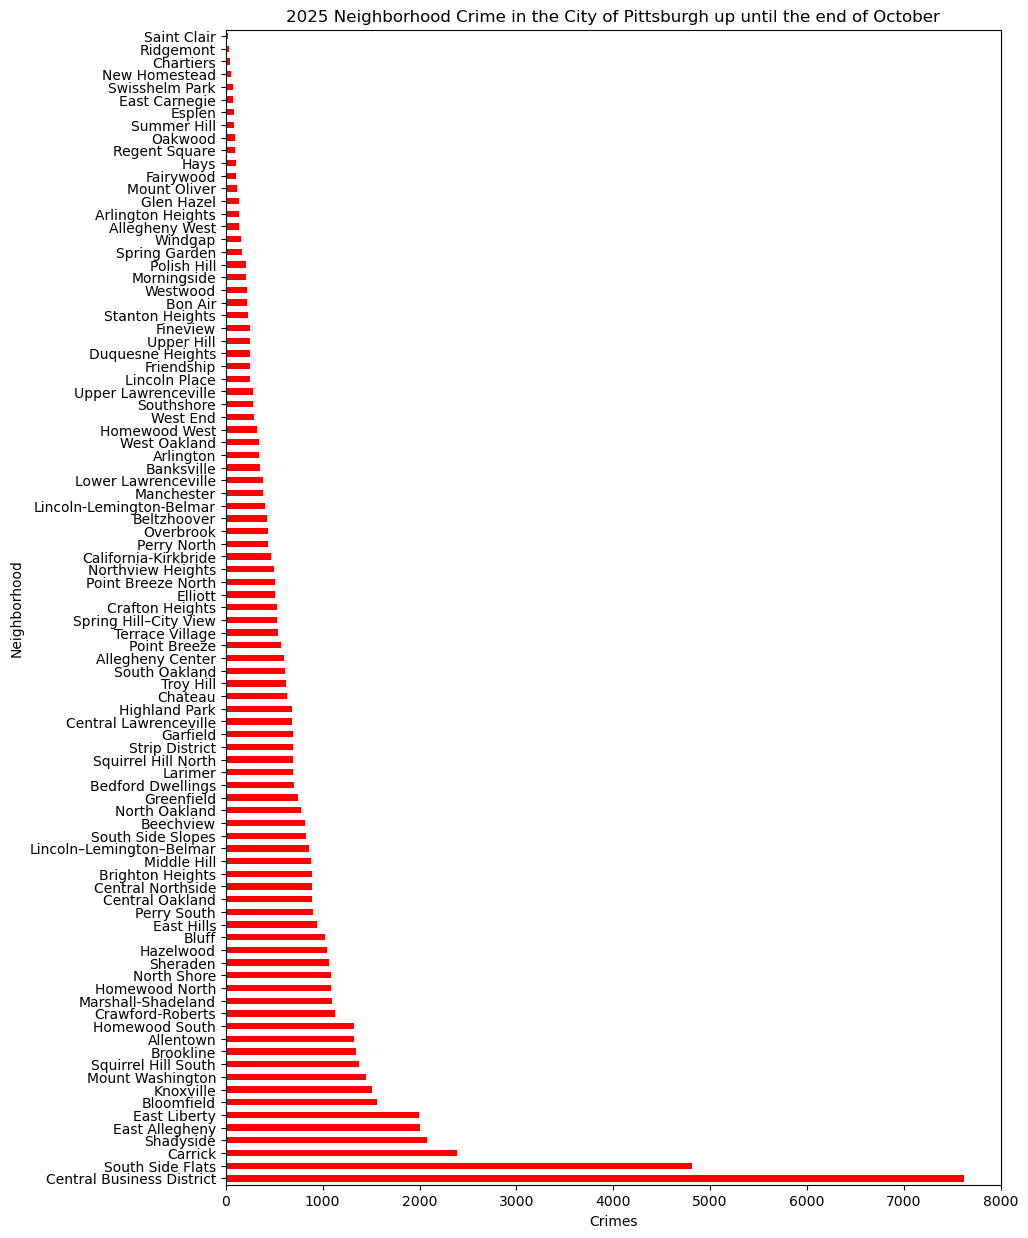

In [7]:
neighborhood_crime = ['_id','Neighborhood']
df = pd.read_csv(crime, usecols = neighborhood_crime)
quant = df['Neighborhood'].value_counts()
quant.plot.barh(figsize = (10,15), color = 'red')
plt.title("2025 Neighborhood Crime in the City of Pittsburgh up until the end of October")
plt.xlabel("Crimes")
plt.show()
last_20 = quant.iloc[-20:]

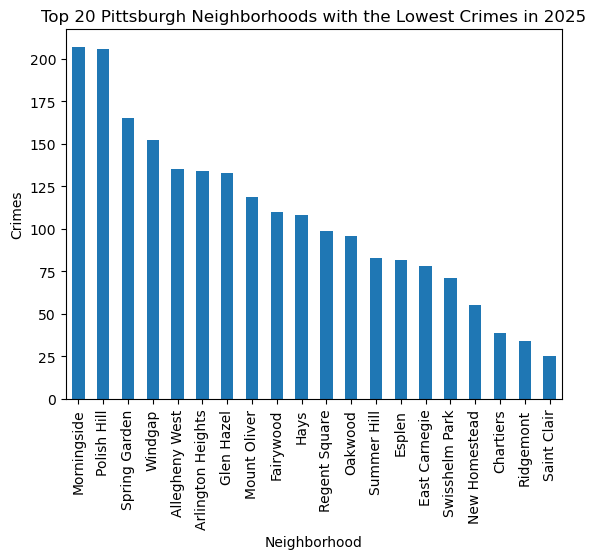

In [8]:
lowest_crime = last_20.plot.bar()
plt.xlabel("Neighborhood")
plt.ylabel("Crimes")
plt.title("Top 20 Pittsburgh Neighborhoods with the Lowest Crimes in 2025")
plt.show()

# What did we find?

After extracting the data from the monthly crime value, I sorted by neighborhoods that were grouped significantly by each unique id number, which was capable of gauging the quantity of crimes committed in 2025 per neighborhood. I then took this data and formulated it into a bar chart of only the neighborhoods with the lowest amount of crimes. I was then able to conclude that Saint Clair could be considered the safest neighborhood by this yearly crime metric in the city of Pittsburgh. This can be better conveyed by assigning a submetric for each neighborhood based on how few crimes have been committed.

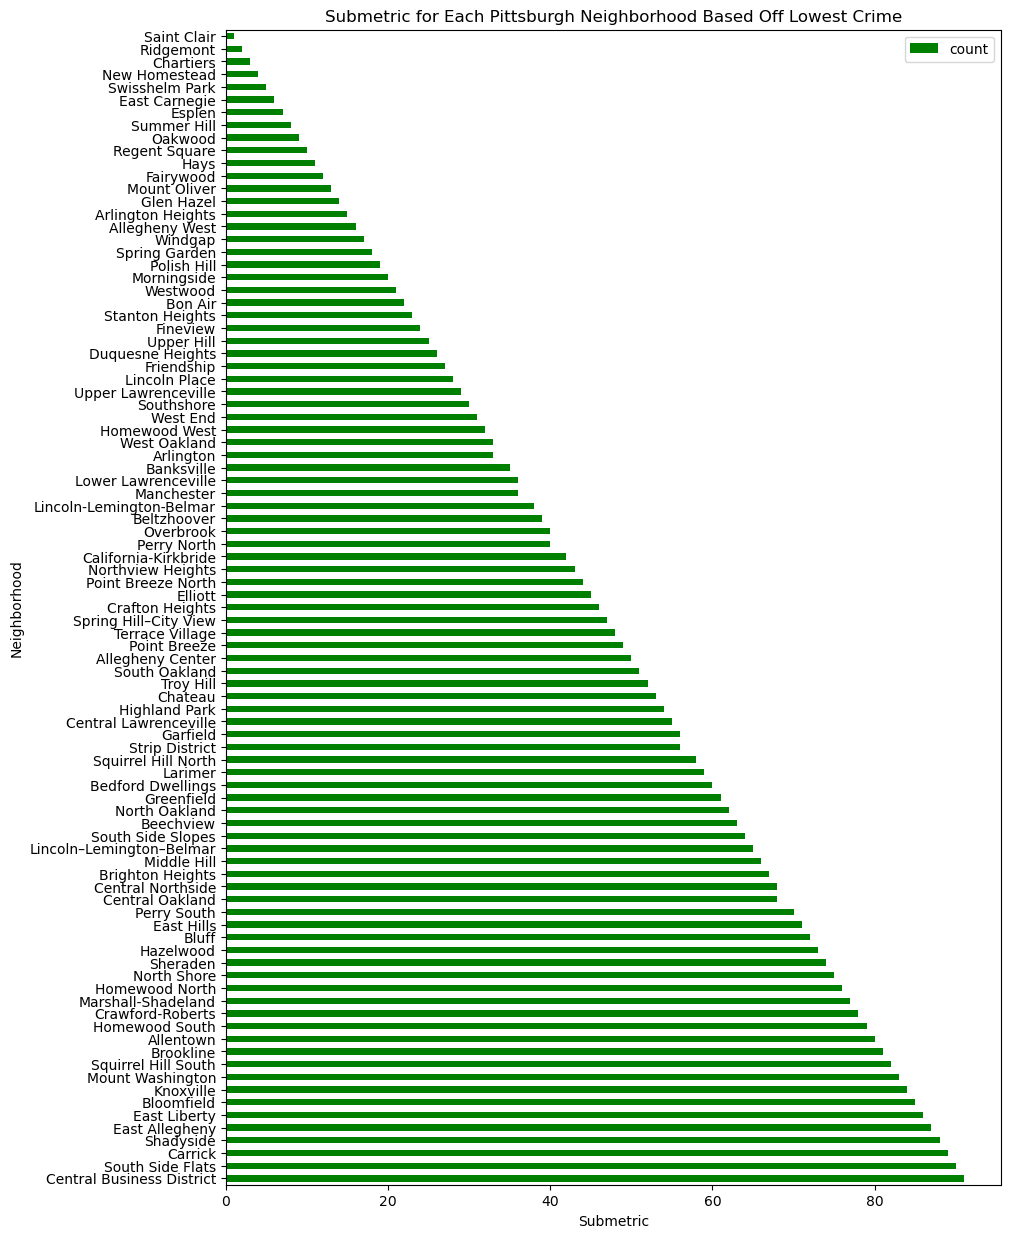

In [4]:
sorted_quant = quant.sort_values(ascending = False)
submetrics = sorted_quant.rank(method = 'min', ascending = True)
submetrics_df = pd.DataFrame(submetrics)
submetrics_plot = submetrics_df.plot.barh(figsize = (10,15), color = 'green', xlabel = "Submetric", ylabel = "Neighborhood")
plt.title("Submetric for Each Pittsburgh Neighborhood Based Off Lowest Crime")
plt.show()

As we can see, by sorting into a submetrics DataFrame, Saint Clair remains at the top for what we define as the 'safest neighborhood.' After which, the rest of the neighborhoods follow suit. By accumulating every neighborhood, and assigning each neighborhood a submetric similar to a 'rank', we may define each of the datasets into one overall average metric. By doing so, we can determine what the overall best neighborhood is. 

In [10]:
crc = submetrics_df.to_csv('unfinished_crime_submetric.csv', index = True)
crc = pd.read_csv('unfinished_crime_submetric.csv')
crc_df = (crc.rename(columns = {'count' : 'Submetric Score'}).sort_values(by = 'Submetric Score', ascending = True))
crc_df['Submetric Score'] = crc_df['Submetric Score'].round().astype(int)
crc_df.to_csv('crime_submetrics.csv', index = None)

# Conclusion

To conclude, based on the present data collected from this dataset, we may determine that Saint Clair may be considered to be the safest or 'best' neighborhood. This is due to a survey on total crime in the year 2025, leading up to September. The quantity of crimes remained fewer than in any other neighborhood and therefore made it plausible to assign a rank of 1.

# What are some limitations?

Some limitations of this study are the lack of consideration for types of neighborhoods where underreporting may be more common. Not every neighborhood has the same stance on reporting and might handle issues more in-house. There is also the idea that if some of these neighborhoods just have a lower population, then the number of crimes would just be smaller than in a bigger area of the city.